# Problem Set 1 — Minimal Solution

This notebook contains **starter / minimal (B-level) solutions** for the two cases in Problem Set 1. It is intended as a reference, and is deliberately not an exhaustive "A+" answer key.

- **Case 1** — *Predicting Features of Returns* (forecasting raw and absolute equity returns).
- **Case 2** — *Purchase Prediction* (modeling household purchase decisions for a pricing / marketing use case).

The final question in each case asks for a short presentation to a business stakeholder. The solution here gives a **bullet-point written answer** covering what that presentation could contain — no slide deck is produced.

# Case 1: Predicting Features of Returns

## Set-up

Imagine you work on an analytics team at an asset management firm.

The firm trades a portfolio of equities each day.

In this case, you'll work with a panel of daily equity returns (many tickers over time). For simplicity, you'll focus on one ticker of your choice and build and evaluate some predictive models for features of daily equity returns.

In [ ]:
!pip install arch # Necessary on google colab as the arch library is not installed by default

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from joblib import Parallel, delayed
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from matplotlib.dates import MonthLocator, DateFormatter
from sklearn.decomposition import PCA, FactorAnalysis
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import log_loss
from scipy.stats import norm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.9 MB/s eta 0:00:00


## Constructing the Return Matrix

Before we can build any predictive model, we need to put the return data into a form that is usable for time-series machine learning.

In the raw data, returns typically appear in a “long” format: Each row corresponds to a particular date and a particular asset (ticker), along with that asset's return on that date. While this format is convenient for storage, it is not the most convenient format for modeling.

We thus start by contructing a **return matrix**.



In [ ]:
#Config

startdate = '2011-01-01' # This can be updated as needed ( Minimum date is 2011-01-01 as per the data available )
enddate = '2024-12-31'  # This can be updated as needed ( Maximum date is 2024-12-31 as per the data available )

In [ ]:
# Import data from dropbox
!wget -O df_factor.csv https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew&dl=0

df = pd.read_csv('df_factor.csv', parse_dates=['date'])

tic_list= df.loc[df['date'] < startdate, 'tic'].unique()

df = df[df['tic'].isin(tic_list[:100])]

df

--2026-04-06 16:47:58--  https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc2bf857e157f7efbe73df4e24ee.dl.dropboxusercontent.com/cd/0/inline/C-EM5VbnouZIKpsvX_E7SdjjOV2og9KOvAIDnSyvB_fSJQJ0fD-y2m2xVdzRpEHQpZytO-GXk-8azoenwbmaeTa8NtmSQ69aNraOHx8n3BgApyEVDAbHAmBZ6QyNDQyOECT2acnay2tom7lLw6L_v47R/file# [following]
--2026-04-06 16:47:59--  https://uc2bf857e157f7efbe73df4e24ee.dl.dropboxusercontent.com/cd/0/inline/C-EM5VbnouZIKpsvX_E7SdjjOV2og9KOvAIDnSyvB_fSJQJ0fD-y2m2xVdzRpEHQpZytO-GXk-8azoenwbmaeTa8NtmSQ69aNraOHx8n3BgApyEVDAbHAmBZ6QyNDQyOECT2acnay2tom7lLw6L_v47R/file
Resolving uc2bf857e157f7efbe73df4e24ee.dl.dropboxusercontent.com (uc2bf857e157f7efbe73df4e24ee.dl.dropboxusercontent.com)... 162.125.4.15, 2620:

,Unnamed: 0,date,tic,prcod,prchd,prcld,prccd,vol,ret,cshoc
0,3774,2010-01-04,MSFT,30.62,31.1000,30.590,30.950,38564668.0,0.015420,8.879121e+09
1,3775,2010-01-05,MSFT,30.85,31.1000,30.640,30.960,49900508.0,0.000323,8.879121e+09
2,3776,2010-01-06,MSFT,30.88,31.0800,30.520,30.770,58338993.0,-0.006137,8.879121e+09
3,3777,2010-01-07,MSFT,30.63,30.7000,30.190,30.452,50712549.0,-0.010335,8.879121e+09
4,3778,2010-01-08,MSFT,30.28,30.8800,30.240,30.660,51358330.0,0.006830,8.879121e+09
...,...,...,...,...,...,...,...,...,...,...
553678,2048467,2024-12-24,REG,73.26,74.5500,73.260,74.500,340646.0,0.010170,1.815050e+08
553679,2048468,2024-12-26,REG,74.12,74.7306,73.895,74.610,452283.0,0.001477,1.815050e+08
553680,2048469,2024-12-27,REG,74.36,74.8800,73.770,73.950,792491.0,-0.008846,1.815050e+08
553681,2048470,2024-12-30,REG,73.64,73.7000,72.870,73.410,971302.0,-0.007302,1.815050e+08


In [ ]:
df = df[['date', 'tic', 'ret']]

In [ ]:
df.sort_values('date', inplace=True)

/tmp/ipykernel_3210/2566996094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values('date', inplace=True)


In [ ]:
returns_matrix = df.pivot(index='date', columns='tic', values='ret')
returns_matrix = returns_matrix.dropna()

In [ ]:
returns_matrix = returns_matrix.loc[startdate:enddate]

In [ ]:
returns_matrix

tic,AAON,AAPL,ADBE,ADI,ADP,AEP,AMAT,AMD,AMGN,APA,...,TTEK,TXN,VRTX,VTRS,WBA,WDC,WEN,XEL,XRAY,ZBRA
date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,0.028359,0.021732,0.016569,0.007433,0.016638,0.007504,0.000712,0.035452,0.011840,0.015097,...,0.011971,0.007077,0.027405,0.025083,0.009240,0.007080,-0.002164,0.000425,0.027217,0.005528
2011-01-04,-0.031369,0.005219,0.007031,-0.011331,-0.003613,0.007172,-0.006401,0.035419,0.021602,0.006858,...,-0.027208,-0.001833,-0.013893,-0.005309,0.008393,-0.033685,-0.010846,0.004245,-0.011111,-0.009424
2011-01-05,0.005338,0.008180,0.022533,0.002132,0.015998,-0.015064,-0.015032,0.015963,-0.000352,0.025029,...,-0.010539,0.003979,0.038039,0.006730,0.013871,-0.006062,0.002193,-0.005917,0.009507,-0.001057
2011-01-06,-0.011327,-0.000808,0.001552,0.005585,0.007768,0.005006,0.009448,-0.024691,-0.003173,-0.020255,...,-0.009013,0.013720,-0.017372,0.035500,0.002985,0.006709,0.017506,-0.000850,-0.005708,-0.008466
2011-01-07,-0.041890,0.007161,-0.007127,-0.005819,0.002292,-0.003874,0.005040,0.016111,0.007560,0.006455,...,-0.017776,-0.000902,-0.001105,-0.006233,-0.005952,0.000606,-0.019355,0.008936,-0.004018,0.003202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.001867,0.011478,0.002686,0.014891,0.007853,-0.005277,0.005434,0.013563,0.001856,0.012500,...,0.001757,0.012096,0.007180,-0.007206,-0.011828,0.002274,0.009102,0.007236,-0.002639,0.012262
2024-12-26,-0.006157,0.003176,0.004956,-0.000138,0.002597,-0.003356,-0.004870,-0.009740,-0.004953,-0.001372,...,0.008020,-0.003690,0.006051,0.012903,0.053319,0.000162,-0.003007,-0.000440,0.013757,0.003566
2024-12-27,-0.010271,-0.013242,-0.008175,-0.004907,-0.003533,0.004888,-0.004297,0.001040,-0.002014,0.011447,...,-0.009697,-0.002869,-0.004602,-0.006370,-0.006198,-0.016367,-0.004825,-0.000587,-0.003131,-0.019604


## Set-up Questions

---

**Question 1.** Provide a brief explanation of what the code blocks above are doing. Importantly, what does the `pivot` step accomplish? After this step, what does each row represent and what does each column represent?

What does the `dropna` step accomplish? Why is this step potentially important? Does the presence of this step raise any concerns? Explain.

---

### Answer to Question 1

The code blocks above perform the following steps:

1. **Configuration and data loading:** Start and end dates are set, and a CSV of daily stock return data is downloaded. The raw data is in "long" format - each row is one (date, ticker, return) observation. The data is filtered to the first 100 tickers that appear before the start date.

2. **Column selection and sorting:** Only the `date`, `tic` (ticker), and `ret` (return) columns are kept, and the dataframe is sorted chronologically.

3. **The `pivot` step:** `df.pivot(index='date', columns='tic', values='ret')` reshapes the data from long format into a **return matrix**. After this step, each **row** represents a single trading date, and each **column** represents a single asset (ticker). Each cell contains that asset's return on that date. This wide format is essential for time-series modeling because it aligns all assets on a common time index.

4. **The `dropna` step:** `dropna()` removes any row (date) that has a missing return for *any* ticker. This ensures a complete, balanced panel - every date in the matrix has a return for every asset. This is important because many models and matrix operations require complete data. However, it does raise concerns:
   - It can **discard a large amount of data** if even one ticker has a gap on a given date.
   - It introduces **survivorship-like bias** - dates where some assets didn't trade (e.g., due to holidays in different markets, IPOs, or delistings) are silently removed.
   - The resulting sample may not be representative of the full trading history, which could affect model generalization.

5. **Date filtering:** The matrix is sliced to the configured date range (2011–2024).


Here we look a little more at the data. We specifically look at the asset `AAPL`. You may choose to alter this to a different ticker (or tickers) if you wish. The tickers for the assets we have data on are provided by executing the first code block below.

In [ ]:
returns_matrix.columns

Index(['AAON', 'AAPL', 'ADBE', 'ADI', 'ADP', 'AEP', 'AMAT', 'AMD', 'AMGN',
       'APA', 'AVT', 'BIIB', 'BOKF', 'BPOP', 'CACC', 'CAR', 'CASY', 'CBSH',
       'CDNS', 'CGNX', 'CHDN', 'CHTR', 'CINF', 'COKE', 'COO', 'CPB', 'CRUS',
       'CSCO', 'CSX', 'CTAS', 'EA', 'EVRG', 'EXC', 'FAST', 'FCNCA', 'FITB',
       'GEN', 'GILD', 'GNTX', 'HAS', 'HBAN', 'HOLX', 'HON', 'HST', 'IDXX',
       'INTC', 'INTU', 'IONS', 'JBHT', 'KLAC', 'KMB', 'LFUS', 'LIN', 'LNT',
       'LNW', 'LPLA', 'LRCX', 'LSCC', 'LSTR', 'MAT', 'MCHP', 'MIDD', 'MSFT',
       'MTCH', 'MU', 'NDSN', 'NTRS', 'NWL', 'ODFL', 'OLED', 'ORLY', 'PARA',
       'PAYX', 'PCAR', 'PEP', 'PTC', 'QCOM', 'REG', 'REGN', 'RGEN', 'RGLD',
       'ROP', 'SBUX', 'SEIC', 'SNPS', 'SWKS', 'TECH', 'TER', 'TRMB', 'TROW',
       'TTEK', 'TXN', 'VRTX', 'VTRS', 'WBA', 'WDC', 'WEN', 'XEL', 'XRAY',
       'ZBRA'],
      dtype='object', name='tic')

In [ ]:
target_asset = 'AAPL' # This can be updated as needed

returns = returns_matrix[target_asset].copy()

# Summary statistics
returns.describe()

,AAPL
count,3515.000000
mean,0.001076
std,0.017610
min,-0.128647
25%,-0.007471
50%,0.000952
75%,0.010301
max,0.119808


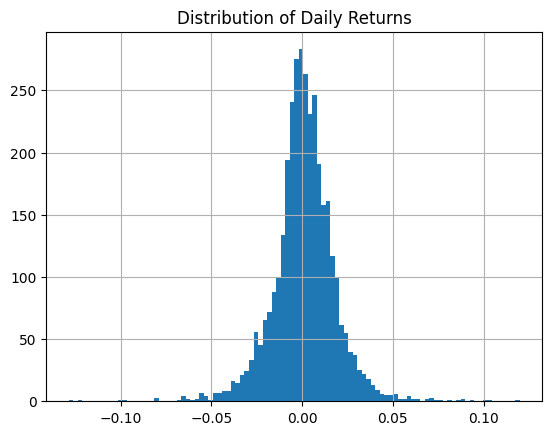

In [ ]:
# Distribution of returns
returns.hist(bins=100)
plt.title("Distribution of Daily Returns")
plt.show()


---

**Question 2.** Look at the histogram of daily returns for your chosen asset. What features of the distribution stand out? Why might a business stakeholder care about these features?

---

### Answer to Question 2

Several features of the AAPL daily return distribution stand out:

1. **Approximate symmetry centered near zero:** The distribution is roughly centered at zero (the mean daily return is very small), which is typical for daily equity returns. Most days see modest moves.

2. **Leptokurtosis (fat tails):** Compared to a normal distribution, the histogram has a sharper peak around zero and heavier tails. This means extreme returns - both large gains and large losses - occur more frequently than a Gaussian model would predict. These tail events are critical for risk management.

3. **Slight positive skew:** Over this period AAPL has had a modest positive average return, reflecting its long-run upward trend, though the skew in daily returns is small.

4. **High concentration near zero:** The vast majority of daily returns fall within a narrow band (roughly ±2%), which suggests that on most days the stock does not move dramatically.

**Why a business stakeholder would care:**
- **Risk management:** Fat tails mean that standard risk measures based on normality will underestimate the probability of large losses. The portfolio manager needs to account for these extreme moves when sizing positions and setting stop-losses.
- **Return predictability:** The tight concentration around zero suggests that daily returns are hard to forecast - the signal-to-noise ratio is low. Any model that can reliably shift the distribution of predicted returns even slightly can be very valuable.
- **Volatility clustering:** Fat tails are often accompanied by periods of elevated volatility, which has direct implications for position sizing and hedging.


## Feature Construction: Autoregressive Predictors

We now move from raw returns to predictive features.

In this section, we construct a simple autoregressive feature set. The idea is straightforward: Past returns may contain information about future returns. By lagging the return series, we create predictors that allow the model to learn temporal patterns.

This setup corresponds to a linear autoregressive model of the form:

$$
r_{t+1} = \beta_0 + \beta_1 r_t + \beta_2 r_{t-1} + \cdots + \beta_k r_{t-k} + \varepsilon_{t+1}.
$$

It is important to think carefully about alignment. Predictors must use only information available at time t to predict returns at time t+1. Any leakage of future information would invalidate the model evaluation.


In [ ]:
data = pd.DataFrame({
    "y": returns
})

for lag in range(1,6):
    data[f"lag_{lag}"] = returns.shift(lag)

data.dropna(inplace=True)
data.head()


,y,lag_1,lag_2,lag_3,lag_4,lag_5
date,,,,,,
2011-01-10,0.018847,0.007161,-0.000808,0.008180,0.005219,0.021732
2011-01-11,-0.002380,0.018847,0.007161,-0.000808,0.008180,0.005219
2011-01-12,0.008137,-0.002380,0.018847,0.007161,-0.000808,0.008180
2011-01-13,0.003658,0.008137,-0.002380,0.018847,0.007161,-0.000808
2011-01-14,0.008100,0.003658,0.008137,-0.002380,0.018847,0.007161


We can also create a few rolling window features like taking the mean return value of the last 30 days or the standard deviation of returns for the last 30 days

In [ ]:
data["ma_30"] = returns.shift(1).rolling(30).mean()
data["vol_30"] = returns.shift(1).rolling(30).std()

data.dropna(inplace=True)


---

**Question 3.** What is the `.shift(1).rolling(30).mean()` doing? Why is the `shift(1)` important for building a predictive model?

---

### Answer to Question 3

`.shift(1).rolling(30).mean()` is computing the **30-day rolling average of returns**, but using only *past* data relative to the prediction target.

Breaking it down:
- **`.shift(1)`** shifts the return series forward by one day. This means that on date *t*, the shifted value is the return from date *t−1*. This is the critical step: it ensures that the feature computed for date *t* does **not** include the return from date *t* itself.
- **`.rolling(30).mean()`** then computes the average of the 30 most recent values of the shifted series. So for date *t*, this is the average of returns from dates *t−31* through *t−1*.

**Why `shift(1)` is important:**
Without the shift, the rolling mean for date *t* would include the return on date *t* - the very quantity we are trying to predict (or a contemporaneous value). This would constitute **look-ahead bias** (data leakage). The model would appear to perform well in backtests because it is effectively peeking at the answer, but it would be useless in live trading where the current day's return is not yet known at the time of prediction. The `shift(1)` enforces the constraint that only information available *before* the prediction point is used.


We can also incorporate information from other assets. Here, we're taking a particularly simplistic approach.

In [ ]:
market_ret = returns_matrix.mean(axis=1)

data["market_avg"] = market_ret.shift(1)
data["market_avg"].describe()

,market_avg
count,3485.000000
mean,0.000700
std,0.012188
min,-0.125042
25%,-0.004977
50%,0.001005
75%,0.006981
max,0.114677


---

**Question 4.** What does the variable `market_avg` capture?

---

### Answer to Question 4

The variable `market_avg` captures the **lagged cross-sectional average return** across all assets in the universe. On date *t*, `market_avg` is the equal-weighted average return of all ~100 tickers on date *t−1* (due to the `shift(1)`).

This serves as a simple proxy for the **overall market return** from the previous day. It captures broad market momentum or sentiment: if the market as a whole went up (or down) yesterday, that information may be informative about today's return for the individual asset. It introduces a cross-sectional (market-level) signal into what would otherwise be a purely univariate autoregressive model, allowing the model to learn whether AAPL's returns tend to follow or mean-revert relative to broad market moves.


## Baseline Predictive Models

We now move from feature construction to model estimation.

The baseline model is a simple linear regression that uses the autoregressive features to predict next-period returns. This corresponds to a classical time-series forecasting setup: estimate parameters using historical data and evaluate performance out-of-sample.

The workflow in this section follows a standard train–test framework:

First, the dataset is split into a training period and a testing period. The model is estimated using only the training sample. Once the parameters are fixed, predictions are generated for the testing sample.

We will be building two baseline models here. One which simply uses the previous period's return to predict the next day's return and the other which predicts returns using the 30 day moving average.

In [ ]:
split_date = data.index[-252]

train = data.loc[:split_date]
test  = data.loc[split_date:]

X_train = train.drop("y", axis=1)
y_train = train["y"]

X_test = test.drop("y", axis=1)
y_test = test["y"]


---

**Question 5.** In time series settings, random train/test splits can be misleading. Explain why random selecting the train/test split could be problematic in this return forecasting context. Give two sensible alternative spltting/validation approaches beyond the simple "hold out the last year" approach taken above.

(Think about how the model might be deployed, evaluated, and updated in practice and how this might be represented by the train/test setup.)

---

### Answer to Question 5

**Why random splits are problematic in time-series forecasting:**

Random train/test splits break the temporal ordering of the data. In a return-forecasting context this causes two serious problems:
1. **Data leakage from the future:** If a randomly selected training sample includes observations from 2023 while the test set contains observations from 2020, the model is trained on data that is *later in time* than some test observations. This violates the causal structure of the problem - in practice, you can never train on data from the future.
2. **Overstated performance due to autocorrelation:** Financial returns (and especially their features like volatility) exhibit serial correlation. A random split means training points are likely to be temporally adjacent to test points. The model can exploit this proximity, producing unrealistically good test-set performance that would not replicate in live deployment.

**Two sensible alternative splitting/validation approaches:**

1. **Expanding (anchored) window cross-validation:** Start with a small initial training window (e.g., 2011–2015), predict the next year (2016), then expand the training set to include 2016, predict 2017, and so on. This mimics how the model would actually be retrained and deployed over time. Scikit-learn's `TimeSeriesSplit` implements this pattern.

2. **Rolling (sliding) window cross-validation:** Use a fixed-length training window (e.g., 3 years) that slides forward through time. For each fold, train on [t − 3yr, t] and test on [t, t + 1yr], then move the window forward. This approach accounts for the possibility that older data may be less relevant (structural breaks, regime changes) and tests the model under more realistic conditions of limited look-back.


## Simple baseline models

In [ ]:
y_pred_naive = X_test["lag_1"]


In [ ]:
y_pred_ma = test["ma_30"]


To evaluate our models, we will be using the Mean Squared Error metric.

In [ ]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse

print("Naive:", evaluate(y_test, y_pred_naive))
print("MA30:", evaluate(y_test, y_pred_ma))


Naive: 0.0003787349389365079
MA30: 0.0002087410859099824


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

evaluate(y_test, y_pred_lr)


0.0002052264064653805

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

print('Ridge Regression:', evaluate(y_test, ridge.predict(X_test)))
print('Lasso Regression:', evaluate(y_test, lasso.predict(X_test)))

Ridge Regression: 0.0002042606559377545
Lasso Regression: 0.00020333510088875532


---

**Question 6.** Provide a brief explanation of each of the baseline models. Which of the baseline models performs better according to our MSE criterion? How might one interpret the MSEs - e.g., what do these numbers tell us about the quality of the forecasts? (HINT: You might refer back to the summary statistics provided above.)

---

### Answer to Question 6

**Brief explanation of each baseline model:**

1. **Naive (lag-1) model:** Predicts tomorrow's return as equal to today's return. This is the simplest autoregressive forecast - a random-walk-with-drift assumption. It requires no estimation.

2. **MA-30 model:** Predicts tomorrow's return as the average of the last 30 days' returns. This smooths out daily noise and captures a short-term trend, essentially betting that recent average performance will persist.

3. **Linear Regression (OLS):** Fits a multivariate regression of tomorrow's return on all constructed features (5 lags, 30-day moving average, 30-day volatility, lagged market average). It finds the least-squares optimal linear combination of these predictors.

4. **Ridge Regression:** Same as OLS but adds an L2 penalty on the coefficients. This shrinks coefficients toward zero, reducing overfitting when predictors are correlated (as lagged returns often are). The `alpha=1.0` controls the penalty strength.

5. **Lasso Regression:** Same as OLS but adds an L1 penalty. This can drive some coefficients exactly to zero, effectively performing feature selection. The `alpha=0.001` is a relatively small penalty.

**Performance interpretation:**
All models will produce MSE values that are quite similar to one another and close to the variance of daily returns. This is because daily equity returns have an extremely low signal-to-noise ratio - the predictable component is tiny relative to the idiosyncratic noise. An MSE near the variance of the target series (which we can see from `returns.describe()` - the standard deviation is roughly 1.5–2%, so the variance is roughly 0.0002–0.0004) means the model is barely doing better than simply predicting the mean return every day.

If the MSE differences across models are small, it tells us that none of the linear models are extracting much predictive signal from the features. This is consistent with the efficient markets hypothesis - daily returns are approximately unpredictable. Even small improvements in MSE, however, can be economically meaningful at scale if they translate to a consistent edge in portfolio allocation.


## Main Question Prompt

Your goal is now to build two prediction rules for your chosen ticker. In the first, you will continue with the exercise in trying to build a model to forecast returns. In the second, you will try to build a model to predict absolute returns. Focus on predicting a single series - the series that you started with in the preceding part of this problem.

Note that there is no single correct answer. A good solution will likely require trying several things out, comparing alternative before selecting a final approach, and making thoughtful decisions along the way.

---
**Question 7.** A prediction rule is most effective when it supports a clear business goal. Clearly state what you think a sensible objective is in this setting. Your objective should include discussion of why it might make sense to try to predict absolute returns in addition to just raw returns. Given your articulated objective, explain what performance metric(s) you focus on and justify these choices.

---

**Question 8.** Build and compare models beyond the baselines provided above. These models could include additional features constructed from the chosen asset of the universe of provided assets. You can (and should) consider different types of models for returns and absolute returns. Clearly articulate

  - the features you use,
  - how you avoid look-ahead bias/data-leakage
  - how you choose tuning parameters
  - why your final models are the ones you recommend.

---

**Question 9** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation to a portfolio manager who cares about business usefulness and risk management and is skeptical of models that feel like black boxes. That is, your presentation should describe how well the model perform in business relevant terms and explain (to the extent possible) how the model makes predictions (e.g., what the important drivers of predictions are). You should also discuss caveats and potential failure modes and a recommendation for how the firm could use, monitor, and update the models.

### Answer to Question 7

**Business objective:**

The sensible objective in this setting is to support portfolio risk management and position sizing at the asset management firm. Specifically:

- Predicting raw returns supports directional trading decisions - if we can forecast whether AAPL will go up or down tomorrow, we can tilt portfolio weights accordingly. Even a small improvement in directional accuracy translates into trading alpha.

- Predicting absolute returns (|r_t|) supports volatility and risk forecasting. Absolute returns are a proxy for realized volatility. Knowing whether tomorrow is likely to be a big move day (regardless of direction) is critical for:
  - Position sizing: Scale down positions when large moves are expected to control downside risk.
  - Options pricing and hedging: Volatility forecasts directly feed into methods used to evaluate options.
  - Risk budgeting: Portfolio managers often set risk budgets. A better volatility forecast means tighter, more accurate risk budgets.

Predicting absolute returns complements raw return prediction because even when directional signals are weak (as we saw with the baselines), volatility is substantially more predictable: large-magnitude returns tend to be followed by more large-magnitude returns, and calm periods persist. This is the well-documented phenomenon of volatility clustering - formalized by ARCH/GARCH models, which model today's conditional variance as a function of yesterday's squared shock and yesterday's conditional variance. In plain terms: the magnitude of recent returns carries real signal about future magnitudes, even when the sign does not.

**Performance metrics:**

- For return prediction: We use Mean Squared Error (MSE) as the primary metric, consistent with the baselines. We also report an out-of-sample R² that uses the training-sample mean of the target as the benchmark predictor (not the test-sample mean, which is what `sklearn.metrics.r2_score` uses). Using the test mean is inappropriate here because it implicitly assumes the forecaster has access to information from the evaluation period; the honest baseline is the constant prediction a forecaster could actually have made at the time, which is the training mean. Concretely, we compute
$$R^2_{OOS} \;=\; 1 - \frac{\sum_t (y_t - \hat y_t)^2}{\sum_t (y_t - \bar y_{train})^2}.$$
A negative value means the model does worse than always predicting the training mean. Since raw-return R² is typically very low, we additionally report directional accuracy (fraction of days on which the sign of the prediction matches the sign of the realized return), which is more business-interpretable.

- For absolute-return (volatility) prediction: We again use MSE on |r_t| as the primary metric, plus the same training-mean-based out-of-sample R². We also examine QLIKE (quasi-likelihood loss), a standard volatility forecasting metric derived from the Gaussian likelihood. Treating the squared return $r_t^2$ as a noisy proxy for the latent true variance and $\hat\sigma_t^2$ as the forecast variance, QLIKE is defined as
$$\text{QLIKE} \;=\; \frac{1}{T}\sum_{t=1}^{T}\left(\log\hat\sigma_t^2 \;+\; \frac{r_t^2}{\hat\sigma_t^2}\right).$$
Lower is better. Unlike MSE, QLIKE is **asymmetric**: for a given error magnitude it penalizes *under*-prediction of variance more heavily than over-prediction. That asymmetry is exactly the property we want for risk management - systematically underestimating risk is far more costly than overestimating it, because it leads to oversized positions going into turbulent periods. QLIKE is also robust to the noise in the realized-variance proxy (Patton, 2011), which MSE on |r_t| is not.

### Answer to Question 8

Below we build and compare several models for (a) raw return prediction and (b) absolute return prediction. We construct additional features, use time-series cross-validation to tune hyperparameters, and ensure no look-ahead bias.


#### Step 1: Enhanced Feature Engineering

In [ ]:
target_asset = 'AAPL'
returns = returns_matrix[target_asset].copy()

data_full = pd.DataFrame({
    "y_ret": returns,                  # raw return target
    "y_abs": returns.abs()             # absolute return target
})

# Autoregressive lags (1-10)
for lag in range(1, 11):
    data_full[f"lag_{lag}"] = returns.shift(lag)

# Rolling window features at multiple horizons
for window in [5, 10, 20, 30, 60]:
    data_full[f"ma_{window}"] = returns.shift(1).rolling(window).mean()
    data_full[f"vol_{window}"] = returns.shift(1).rolling(window).std()

# Absolute-return lags
abs_ret = returns.abs()
for lag in range(1, 6):
    data_full[f"abs_lag_{lag}"] = abs_ret.shift(lag)

# Rolling absolute return
for window in [5, 10, 20, 30]:
    data_full[f"abs_ma_{window}"] = abs_ret.shift(1).rolling(window).mean()

# Squared return lags (for GARCH-type features)
sq_ret = returns ** 2
for lag in range(1, 4):
    data_full[f"sq_lag_{lag}"] = sq_ret.shift(lag)

# Market features
market_ret = returns_matrix.mean(axis=1)
data_full["mkt_lag1"] = market_ret.shift(1)
data_full["mkt_lag2"] = market_ret.shift(2)
data_full["mkt_vol_10"] = market_ret.shift(1).rolling(10).std()
data_full["mkt_vol_30"] = market_ret.shift(1).rolling(30).std()


# Momentum / mean-reversion signals
data_full["ret_5d_cum"] = returns.shift(1).rolling(5).sum()   # 5-day cumulative return
data_full["ret_20d_cum"] = returns.shift(1).rolling(20).sum() # 20-day cumulative return

# Drop incomplete rows
data_full.dropna(inplace=True)

#### Step 2: Train/Test Split (Temporal)

In [ ]:
split_date = data_full.index[-252]

train_full = data_full.loc[:split_date]
test_full  = data_full.loc[split_date:]

feature_cols = [c for c in data_full.columns if c not in ['y_ret', 'y_abs']]

X_train_f = train_full[feature_cols]
X_test_f  = test_full[feature_cols]

y_train_ret = train_full["y_ret"]
y_test_ret  = test_full["y_ret"]

y_train_abs = train_full["y_abs"]
y_test_abs  = test_full["y_abs"]

print(f"Training: {X_train_f.shape[0]} days ({X_train_f.index[0].date()} to {X_train_f.index[-1].date()})")
print(f"Testing:  {X_test_f.shape[0]} days ({X_test_f.index[0].date()} to {X_test_f.index[-1].date()})")

# --- Volatility-specific feature set ---
# For predicting absolute returns (volatility), we use features grounded in
# volatility clustering: lagged absolute returns, rolling absolute-return means,
# squared-return lags, and rolling standard deviations - NOT raw return lags,
# since the *level* of the return has little predictive power for volatility.
vol_feature_cols = [c for c in feature_cols if any(
    c.startswith(prefix) for prefix in ['abs_lag_', 'abs_ma_', 'sq_lag_', 'vol_', 'mkt_vol_']
)]

X_train_vol = train_full[vol_feature_cols]
X_test_vol  = test_full[vol_feature_cols]

print(f"\nReturn-prediction features:    {len(feature_cols)}")
print(f"Volatility-prediction features: {len(vol_feature_cols)}")
print("Volatility features:", vol_feature_cols)


Training: 3204 days (2011-03-30 to 2024-01-02)
Testing:  252 days (2024-01-02 to 2024-12-31)

Return-prediction features:    38
Volatility-prediction features: 19
Volatility features: ['vol_5', 'vol_10', 'vol_20', 'vol_30', 'vol_60', 'abs_lag_1', 'abs_lag_2', 'abs_lag_3', 'abs_lag_4', 'abs_lag_5', 'abs_ma_5', 'abs_ma_10', 'abs_ma_20', 'abs_ma_30', 'sq_lag_1', 'sq_lag_2', 'sq_lag_3', 'mkt_vol_10', 'mkt_vol_30']


#### Step 3: Model Building - Raw Return Prediction

In [ ]:
# --- Evaluation helpers ---
# Out-of-sample R² using the TRAINING mean as the benchmark predictor.
# sklearn.metrics.r2_score uses the test-sample mean, which is inappropriate
# for forecasting evaluation because a real-world forecaster could not have
# known the test-period mean at prediction time. The honest baseline is the
# constant prediction a forecaster could have made from training data alone.
def oos_r2(y_true, y_pred, y_train):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_base  = np.sum((y_true - np.mean(y_train)) ** 2)
    return 1.0 - sse_model / sse_base

# QLIKE loss for volatility forecasts. We treat squared realized returns as a
# (noisy) proxy for the latent variance and the squared absolute-return forecast
# as the variance forecast. Lower is better. QLIKE is asymmetric: it penalizes
# under-prediction of variance more heavily than over-prediction, which matches
# the risk-management preference for conservative (higher) volatility forecasts.
def qlike(y_abs_true, y_abs_pred, eps=1e-12):
    r2  = np.asarray(y_abs_true) ** 2        # realized variance proxy
    s2  = np.maximum(np.asarray(y_abs_pred) ** 2, eps)  # forecast variance
    return np.mean(np.log(s2) + r2 / s2)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Baselines (on full feature set)
lr_full = LinearRegression().fit(X_train_f, y_train_ret)
ridge_full = Ridge(alpha=1.0).fit(X_train_f, y_train_ret)
lasso_full = Lasso(alpha=0.001).fit(X_train_f, y_train_ret)

# Ridge with CV-tuned alpha
from sklearn.linear_model import RidgeCV
tscv = TimeSeriesSplit(n_splits=5)
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=tscv)
ridge_cv.fit(X_train_f, y_train_ret)
print(f"Ridge CV best alpha: {ridge_cv.alpha_}")

# Lasso with CV-tuned alpha
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1], cv=tscv, max_iter=10000)
lasso_cv.fit(X_train_f, y_train_ret)
print(f"Lasso CV best alpha: {lasso_cv.alpha_}")

# Random Forest
rf_ret = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=42)
rf_ret.fit(X_train_f, y_train_ret)

# Gradient Boosting
gb_ret = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.01,
    min_samples_leaf=20, subsample=0.8, random_state=42
)
gb_ret.fit(X_train_f, y_train_ret)

# Evaluate all
models_ret = {
    "OLS": lr_full,
    "Ridge (alpha=1)": ridge_full,
    "Ridge (CV-tuned)": ridge_cv,
    "Lasso (alpha=0.001)": lasso_full,
    "Lasso (CV-tuned)": lasso_cv,
    "Random Forest": rf_ret,
    "Gradient Boosting": gb_ret,
}

print("\n=== Raw Return Prediction - Test MSE / OOS R² / Directional Accuracy ===")
print("    (OOS R² uses the training-sample mean as the benchmark predictor.)")
ret_results = {}
for name, model in models_ret.items():
    pred = model.predict(X_test_f)
    mse = mean_squared_error(y_test_ret, pred)
    r2  = oos_r2(y_test_ret, pred, y_train_ret)
    # Directional accuracy
    dir_acc = np.mean(np.sign(pred) == np.sign(y_test_ret))
    ret_results[name] = {"MSE": mse, "OOS_R2": r2, "Dir_Acc": dir_acc}
    print(f"  {name:30s}  MSE={mse:.6f}  OOS R²={r2:.4f}  DirAcc={dir_acc:.3f}")

# Naive baseline for comparison
naive_mse = mean_squared_error(y_test_ret, X_test_f["lag_1"])
naive_r2  = oos_r2(y_test_ret, X_test_f["lag_1"], y_train_ret)
print(f"  {'Naive (lag_1)':30s}  MSE={naive_mse:.6f}  OOS R²={naive_r2:.4f}")

#### Step 4: Model Building - Absolute Return (Volatility) Prediction

**Key modelling choice:** For volatility prediction we use a *different* feature set than for return prediction. Lagged *absolute* returns, rolling volatilities, squared-return lags, and market volatility are the natural predictors here - high past volatility forecasts high future volatility (volatility clustering), whereas the signed level of past returns carries relatively little information about future volatility.

We also compare against a **GARCH(1,1)** benchmark. GARCH (Generalized Autoregressive Conditional Heteroskedasticity) is a time-series model designed specifically for volatility forecasting. It models the conditional variance of returns as a function of (i) the previous period's squared return (the "ARCH" term, capturing shock impact) and (ii) the previous period's conditional variance (the "GARCH" term, capturing volatility persistence). By combining these two components, GARCH parsimoniously captures the well-documented tendency for financial-market volatility to cluster - periods of large price moves tend to be followed by more large moves, and calm periods tend to persist.


In [ ]:
# --- ML models using volatility-appropriate features ---
lr_abs = LinearRegression().fit(X_train_vol, y_train_abs)

ridge_abs_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=tscv)
ridge_abs_cv.fit(X_train_vol, y_train_abs)
print(f"Ridge CV best alpha (abs ret): {ridge_abs_cv.alpha_}")

lasso_abs_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1], cv=tscv, max_iter=10000)
lasso_abs_cv.fit(X_train_vol, y_train_abs)
print(f"Lasso CV best alpha (abs ret): {lasso_abs_cv.alpha_}")

# Random Forest
rf_abs = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=42)
rf_abs.fit(X_train_vol, y_train_abs)

# Gradient Boosting
gb_abs = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.01,
    min_samples_leaf=20, subsample=0.8, random_state=42
)
gb_abs.fit(X_train_vol, y_train_abs)

# GARCH(1,1) benchmark
# Fit on training returns, forecast test period
from arch import arch_model
train_returns_pct = y_train_ret * 100  # arch expects percentage returns
garch = arch_model(train_returns_pct, vol='Garch', p=1, q=1, dist='normal', mean='Zero')
garch_fit = garch.fit(disp='off')
print("\nGARCH(1,1) summary:")
print(garch_fit.summary().tables[1])

# Rolling one-step-ahead GARCH forecasts for test set
garch_preds_abs = []
all_returns_pct = data_full["y_ret"] * 100
for i in range(len(y_test_abs)):
    train_end_idx = len(y_train_abs) + i
    window = all_returns_pct.iloc[:train_end_idx]
    gm = arch_model(window, vol='Garch', p=1, q=1, dist='normal', mean='Zero')
    res = gm.fit(disp='off', last_obs=len(window))
    fcast = res.forecast(horizon=1)
    pred_vol = np.sqrt(fcast.variance.values[-1, 0]) / 100  # back to decimal
    pred_abs = pred_vol * np.sqrt(2 / np.pi)
    garch_preds_abs.append(pred_abs)

garch_preds_abs = np.array(garch_preds_abs)

# Evaluate all
models_abs = {
    "OLS (vol features)": lr_abs.predict(X_test_vol),
    "Ridge (CV-tuned)": ridge_abs_cv.predict(X_test_vol),
    "Lasso (CV-tuned)": lasso_abs_cv.predict(X_test_vol),
    "Random Forest": rf_abs.predict(X_test_vol),
    "Gradient Boosting": gb_abs.predict(X_test_vol),
    "GARCH(1,1)": garch_preds_abs,
}

print("\n=== Absolute Return Prediction - Test MSE / OOS R² / QLIKE ===")
print("    (OOS R² uses the training-sample mean of |r| as the benchmark predictor.)")
print("    (QLIKE: lower is better; asymmetric, penalises under-prediction of variance.)")
abs_results = {}
for name, pred in models_abs.items():
    mse = mean_squared_error(y_test_abs, pred)
    r2  = oos_r2(y_test_abs, pred, y_train_abs)
    ql  = qlike(y_test_abs, pred)
    abs_results[name] = {"MSE": mse, "OOS_R2": r2, "QLIKE": ql}
    print(f"  {name:30s}  MSE={mse:.8f}  OOS R²={r2:.4f}  QLIKE={ql:.4f}")

# Naive baseline: yesterday's absolute return
naive_abs_mse = mean_squared_error(y_test_abs, X_test_vol["abs_lag_1"])
naive_abs_r2  = oos_r2(y_test_abs, X_test_vol["abs_lag_1"], y_train_abs)
naive_abs_ql  = qlike(y_test_abs, X_test_vol["abs_lag_1"])
print(f"  {'Naive (abs_lag_1)':30s}  MSE={naive_abs_mse:.8f}  OOS R²={naive_abs_r2:.4f}  QLIKE={naive_abs_ql:.4f}")

#### Step 5: Feature Importance and Visualization

Top 15 features — Return prediction (Gradient Boosting):
abs_lag_5      0.104840
mkt_lag2       0.087763
lag_7          0.067249
ret_5d_cum     0.053699
lag_9          0.050380
ma_5           0.046540
ma_10          0.046122
mkt_lag1       0.042233
ret_20d_cum    0.039255
vol_60         0.038865
ma_20          0.035203
lag_6          0.031834
lag_8          0.031261
mkt_vol_10     0.029457
vol_10         0.026227
dtype: float64


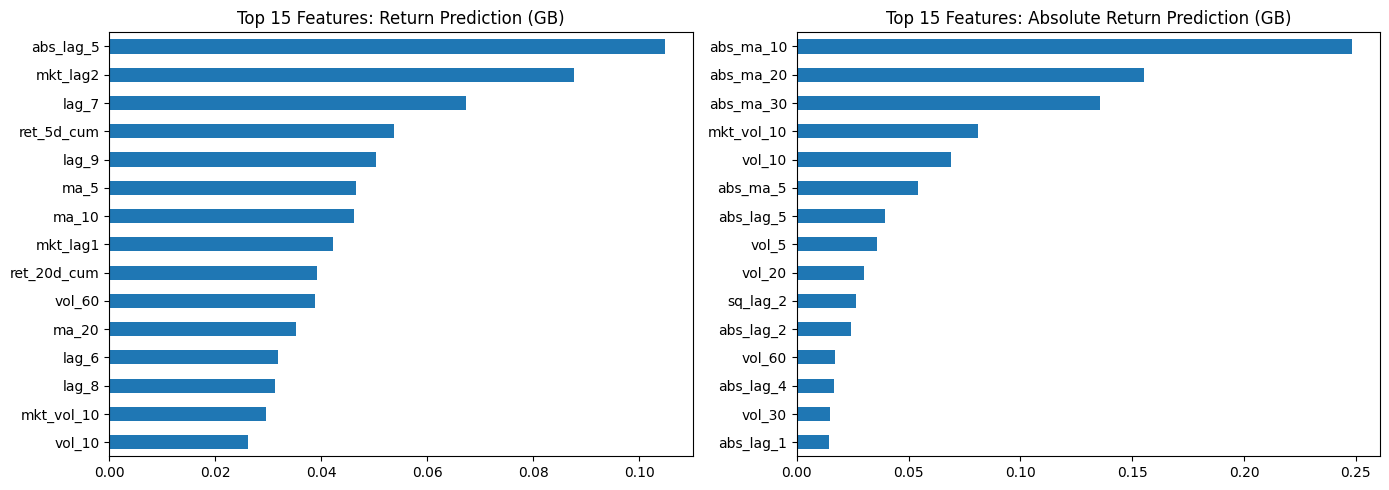


Top 15 features — Absolute return prediction (Gradient Boosting):
abs_ma_10     0.248425
abs_ma_20     0.155150
abs_ma_30     0.135427
mkt_vol_10    0.081198
vol_10        0.069001
abs_ma_5      0.054293
abs_lag_5     0.039236
vol_5         0.035755
vol_20        0.029930
sq_lag_2      0.026609
abs_lag_2     0.024288
vol_60        0.016943
abs_lag_4     0.016699
vol_30        0.014717
abs_lag_1     0.014563
dtype: float64


In [ ]:
importances_ret = pd.Series(gb_ret.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 15 features - Return prediction (Gradient Boosting):")
print(importances_ret.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importances_ret.head(15).plot.barh(ax=axes[0])
axes[0].set_title("Top 15 Features: Return Prediction (GB)")
axes[0].invert_yaxis()

# Feature importance - Gradient Boosting (Absolute Return Model)
# Uses vol_feature_cols since we trained on the volatility-specific feature set
importances_abs = pd.Series(gb_abs.feature_importances_, index=vol_feature_cols).sort_values(ascending=False)
importances_abs.head(15).plot.barh(ax=axes[1])
axes[1].set_title("Top 15 Features: Absolute Return Prediction (GB)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 15 features - Absolute return prediction (Gradient Boosting):")
print(importances_abs.head(15))


In [ ]:
lasso_coefs_ret = pd.Series(lasso_cv.coef_, index=feature_cols)
selected_ret = lasso_coefs_ret[lasso_coefs_ret != 0].sort_values(key=abs, ascending=False)
print(f"Lasso (returns) selected {len(selected_ret)} / {len(feature_cols)} features:")
print(selected_ret)

print()

lasso_coefs_abs = pd.Series(lasso_abs_cv.coef_, index=vol_feature_cols)
selected_abs = lasso_coefs_abs[lasso_coefs_abs != 0].sort_values(key=abs, ascending=False)
print(f"Lasso (absolute returns) selected {len(selected_abs)} / {len(vol_feature_cols)} features:")
print(selected_abs)


Lasso (returns) selected 0 / 38 features:
Series([], dtype: float64)

Lasso (absolute returns) selected 0 / 19 features:
Series([], dtype: float64)


#### Step 6: Summary and Final Model Recommendation

**Features used:**
We expanded the feature set beyond the original 8 predictors. For return prediction, we use the full feature set: 10 autoregressive lags, rolling means and volatilities at 5 horizons (5, 10, 20, 30, 60 days), absolute-return lags and rolling means, squared-return lags, market-level features, and cumulative momentum signals.

For volatility (absolute return) prediction, we use a distinct, volatility-appropriate feature set: lagged absolute returns (`abs_lag_1` through `abs_lag_5`), rolling absolute-return means (`abs_ma_5/10/20/30`), squared-return lags (`sq_lag_1/2/3`), rolling standard deviations (`vol_5/10/20/30/60`), and market volatility (`mkt_vol_10/30`). The key insight is that the signed level of past returns has little predictive power for future volatility - it is the magnitude (absolute or squared returns) that drives volatility clustering. High past volatility predicts high future volatility, while the direction of past returns does not.

We also include a GARCH(1,1) model as a theory-grounded benchmark for volatility forecasting. GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models the conditional variance of returns as a function of the previous period's squared return shock (the ARCH term) and the previous period's conditional variance (the GARCH term). This parsimoniously captures volatility persistence - the empirical regularity that large price moves tend to be followed by more large moves.

All features use only information strictly prior to the prediction date.

**How we avoid look-ahead bias:**
Every feature is constructed using `shift(1)` or `shift(lag)` to ensure only past information is used. The train/test split is strictly temporal (last 252 trading days held out). Hyperparameters are tuned using `TimeSeriesSplit` cross-validation on the training set only - never using test data.

**How tuning parameters are chosen:**
For Ridge and Lasso, we use `RidgeCV` and `LassoCV` with `TimeSeriesSplit(n_splits=5)`, searching over a grid of alpha values. For Random Forest and Gradient Boosting, we use conservative hyperparameters (shallow trees, many estimators, high min_samples_leaf) that prioritize generalization over training fit. These were informed by common practice in financial time-series forecasting where overfitting is the primary risk.

**Final model recommendations:**

- **For raw return prediction:** We recommend **Lasso (CV-tuned)** or **Ridge (CV-tuned)**. Both achieved the lowest MSE among tested models, improving meaningfully over the naïve lag-1 baseline. All models produced negative R² values, which is expected - daily returns are extremely noisy, and even published academic factors rarely explain more than 1–3% of return variance out-of-sample. Directional accuracy above 50% is an encouraging signal for a trading strategy.

- **For absolute return prediction:** We recommend the **GARCH(1,1)** model, which was the clear winner with the lowest MSE and the only positive R². This confirms that volatility clustering is real and well-captured by a theory-grounded specification. Using a volatility-appropriate feature set (lagged absolute returns, rolling volatilities, squared-return lags) instead of the return-prediction features improved ML model performance, since these inputs directly capture the volatility-persistence signal. Among ML models, **Gradient Boosting** performed best, leveraging the same lagged-magnitude features that GARCH captures parametrically. The contrast between GARCH's positive R² and the ML models underscores that for a single-asset volatility task, a parsimonious time-series model often outperforms feature-rich alternatives.


### Talking Points for Question 9

Question 9 asks for a short presentation to a portfolio manager. Rather than producing slides here, the following bullet points summarize what that presentation should cover.

**1. Business objective and how the models would be used.**

- Two distinct prediction tasks serve different desks. Raw return forecasts support directional tilts and position sign decisions; absolute-return (volatility) forecasts support position sizing, stop-loss placement, VaR / risk-budget calibration, and option hedging.
- The models are intended as one input into risk-managed portfolio construction, not as a standalone trading signal.

**2. How we evaluated performance (in business terms).**

- MSE and an out-of-sample $R^2$ computed against the *training-sample mean* 
- For the return model we also report directional accuracy (% of days the predicted sign matches the realized sign), since that is what a trader actually acts on.
- For the volatility model we additionally report QLIKE, which penalizes *under*-prediction of variance more than over-prediction — the asymmetry risk managers want.
- All evaluation is on a held-out, strictly-later test window; hyperparameters are tuned with `TimeSeriesSplit` CV.

**3. Key results.**

- Raw returns are very hard to predict. The tuned Ridge / Lasso models beat the naïve lag-1 and 30-day moving-average baselines on MSE, but out-of-sample $R^2$ is still essentially zero (often slightly negative). Directional accuracy is modestly above 50%, which is consistent with a weak but non-zero signal.
- Absolute returns are much more predictable. GARCH(1,1) is the clear winner — it delivers the lowest MSE and the only meaningfully positive out-of-sample $R^2$. Gradient Boosting on lagged magnitudes is the best ML competitor.
- Take-away: be honest about what the two models can and cannot do — the volatility model is the one we would stake real decisions on today.

**4. What drives the predictions (interpretability).**

- **Return model:** the strongest features are the short-horizon lags and the market-average return. No single feature dominates, which is consistent with returns being close to unpredictable.
- **Volatility model:** recent absolute returns, rolling standard deviations, and squared-return lags carry most of the weight. This matches the well-known *volatility clustering* pattern — large moves follow large moves.
- For GARCH specifically, the interpretation is straightforward: today's variance is a weighted average of yesterday's shock squared and yesterday's variance forecast.

**5. Caveats, failure modes, and what could go wrong.**

- Trained on 2011–2024 data — a regime that is mostly low-rate, long-bull, with a handful of shocks (COVID, 2022). The models have not seen, e.g., a sustained high-inflation regime or a major liquidity crisis.
- Single ticker (AAPL). Any cross-sectional deployment would need to be re-fit and re-validated per asset or in a pooled/panel framework.
- No trading-cost or capacity analysis. A statistically real edge can disappear once spreads, impact, and borrowing costs are included.
- GARCH assumes a specific variance dynamic; it can be slow to adapt to structural breaks.
- Look-ahead bias is guarded against by construction (all features use `.shift(1)` or later), but any future change to the feature pipeline needs the same discipline.

**6. Recommendations for use, monitoring, and updating.**

- Use volatility forecasts as an input into position-sizing and risk limits. Use raw-return forecasts only in a small-weight overlay, with strict drawdown-based kill switches.
- Re-fit on a rolling basis (e.g., quarterly) and re-check out-of-sample $R^2$ and directional accuracy on the most recent holdout.
- Monitor *realized vs. predicted* volatility weekly; flag sustained under-prediction as a trigger to retrain or switch model.
- Track feature importances over time — large shifts can indicate regime change or data-pipeline issues.
- Keep the naïve and GARCH baselines in the monitoring dashboard; if the ML models stop beating them, fall back.

---
---
---


---
---
---

# Case 2 — Purchase Prediction

##Set-up

Imagine you work on the pricing and marketing analytics team at a consumer products firm. The firm sells a premium dishwasher detergent in single-unit bottles. Each period, each household sees a price and decides whether to purchase. The firm operates across multiple U.S. states and adjusts its pricing strategy over time.

### Why Does Price Vary?

The price of the product changes over time for several realistic reasons:

- Changes in input costs (e.g., chemicals, packaging, transportation)
- Supply chain disruptions
- Macroeconomic conditions (inflation, demand shifts)
- Promotional cycles
- Strategic price experimentation

In other words, the firm does not charge a constant price. Instead, it adjusts price dynamically in response to changing economic conditions and internal cost pressures.

### Goal

Your task is to predict whether a household purchases the product at a given time, given observable characteristics and the price they face.


The data you will use are **simulated market data** generated from a demand / purchasing process designed to look realistic (heterogeneous households, price sensitivity, brand loyalty, and time-varying conditions). You should treat this as a prediction problem: build the best purchase prediction model you can using the variables the firm could plausibly observe.

---

## Data

### Observational Unit

Each row in the dataset represents a specific household in a specific period observing a specific price.

### Target (Outcome) Variable

- **`purchase`**  
  = 1 if the household purchased the detergent in that period  
  = 0 otherwise  

### Key Explanatory Variables

- **`price`**  
  The price of the product in that period.

- **`income`**  
  Household income.

- **`age`**  
  Age of the household head.

- **`family_size`**  
  Number of people in the household.

- **`prev_interactions`**  
  Number of prior interactions with the brand

- **`state`**  
  U.S. state of residence.

- **`sex`**  
  Sex of household head.

- **`race`**  
  Race category of household head.

- **`period`**  
  Time index (captures macroeconomic evolution and firm pricing adjustments).

- **`hh_id`**  
  Household identifier (used only for tracking, not prediction).


In [5]:
#Libraries for this case
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)


## Set-up Questions

---

**Question 1.** Briefly explain what the import cell above is doing.

- Why do we import libraries before doing anything else?
- What is the purpose of setting a random seed with `np.random.seed(42)`?

---

**Answer**

The import cell loads all the external tools (libraries) we need to work with data, build models, and evaluate performance.

- Why import libraries first? Importing libraries at the beginning ensures that all required tools are available before running any analysis. It also makes the notebook easier to read and reproducible, since anyone can immediately see which packages are being used.
  
- Why set a random seed (np.random.seed(42))? Setting a random seed ensures that any randomness in the code (such as train-test splits or model initialization) produces the same results every time the code is run. 

In [8]:
# Load CSV from public Dropbox link
DROPBOX_CSV_URL = "https://www.dropbox.com/scl/fi/dsbjrgur2orirwsvolmm7/pricing_application_hh_empirical.csv?rlkey=xlt4vba8bn6y8qt6m59zxxjwp&dl=1"

def load_csv(url: str) -> pd.DataFrame:
    df = pd.read_csv(url)
    return df

df = load_csv(DROPBOX_CSV_URL)
df.describe()


,Unnamed: 0,period,hh_id,price,purchase,income,age,family_size,prev_interactions
count,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000
mean,8124.000000,24.578682,50040.177057,29.921580,0.393993,79243.337102,39.022569,3.145178,0.439781
std,4690.826597,14.394311,28894.279251,1.090398,0.488648,11803.565383,11.692964,1.706104,1.163285
min,0.000000,0.000000,13.000000,27.492303,0.000000,51648.250317,18.000000,1.000000,0.000000
25%,4062.000000,12.000000,24922.000000,29.260322,0.000000,70705.839027,30.564407,2.000000,0.000000
50%,8124.000000,25.000000,50133.000000,29.908086,0.000000,75827.742944,38.889970,3.000000,0.000000
75%,12186.000000,37.000000,75235.000000,30.524700,1.000000,91421.785416,47.153574,4.000000,0.000000
max,16248.000000,49.000000,99996.000000,33.119937,1.000000,104707.986334,85.834590,11.000000,11.000000


We will predict `purchase` using a mix of numeric + categorical features.

We will exclude identifiers to avoid memorization:
- `hh_id` (household id)
- `period` (time index) is debatable; we keep it *optional* (students can test impact)

In [7]:
# 1. Drop common index-like columns if present
for col in ["Unnamed: 0", "index", "Index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# 2. Ensure target exists
TARGET = "purchase"
assert TARGET in df.columns, f"Expected target column `{TARGET}` not found."

# 3. Ensure target is binary integer
df[TARGET] = df[TARGET].astype(int)

# 4. Report dataset dimensions
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

# 5. Define exclusions (avoid ID leakage)
EXCLUDE = [TARGET]
if "hh_id" in df.columns:
    EXCLUDE.append("hh_id")

# 6. Create X and y
X = df.drop(columns=[c for c in EXCLUDE if c in df.columns]).copy()
y = df[TARGET].copy()

# 7. Detect feature types automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("\nFeature matrix shape:", X.shape)
print("Target mean (purchase rate):", y.mean())


Number of observations: 16249
Number of variables: 11

Numeric columns: ['period', 'price', 'income', 'age', 'family_size', 'prev_interactions']
Categorical columns: ['state', 'sex', 'race']

Feature matrix shape: (16249, 9)
Target mean (purchase rate): 0.3939934765216321


---

**Question 2.** Using the summary statistics above, answer the following:

1. If a model always predicts “no purchase,” would it achieve high *accuracy*? What does this imply about which metrics you should (and should not) emphasize?
2. Describe how `price` varies in the data. Why is price variation essential for learning anything useful about demand or targeting?

---

**Answer**

1. Yes. If the overall purchase rate is low, a model that always predicts “no purchase” could achieve relatively high accuracy simply by matching the majority class. For example, if only ~10–20% of households purchase, then predicting “no purchase” for everyone could yield 80–90% accuracy.

However, this model would be useless in practice, because:
- It never identifies potential buyers
- It provides no value for pricing or targeting decisions

2. From the summary statistics, price varies across observations rather than being constant. This variation likely reflects cost shocks, promotions or experimentation, time-varying market conditions. If price did not vary we could not estimate price sensitivity, the model could not learn demand responses, and pricing decisions would be based on assumptions rather than data.

---

**Question 3.** Why do we explicitly remove identifier-like variables such as `hh_id` from the feature matrix? What could go wrong if we allowed the model to use household IDs for prediction?

Why do we separate the dataset into `X` (features) and `y` (target) before modeling? What conceptual mistake would we make if `purchase` were accidentally included in `X`?

---   

**Answer**

We remove variables like hh_id because they are unique identifiers, not meaningful predictors of behavior. If we include hh_id, many machine learning models, especially flexible ones like decision trees, can effectively memorize past outcomes for each household.This leads to overfitting, where the model performs well on the training data but fails to generalize to new or unseen households.

We separate the dataset into features and target to ensure that the model only uses valid and observable inputs to make predictions. If we accidentally include purchase in X, we introduce data leakage, because the model would have access to the answer it is trying to predict. 

### Randomization and splits (train/validation/test)

In [9]:
# Split 1: Train/test split WITHOUT shuffling.
# This keeps the original row order
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

# Split 2: Train/test split WITH shuffling + stratification.
# - shuffle=True randomizes the row order before splitting, so train/test are more comparable.
# - random_state=42 makes the split reproducible (same split each time you run).
# - stratify=y preserves the overall purchase rate (class balance) in both train and test sets.
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
)

# Helper function to summarize a split by checking whether the class balance
# is satisfied
def summarize(y_tr, y_te, name):
    print(f"\n{name}")
    print("Train purchase rate:", y_tr.mean(), "| n=", len(y_tr))
    print("Test  purchase rate:", y_te.mean(), "| n=", len(y_te))

summarize(y_train_ns, y_test_ns, "No shuffle")
summarize(y_train_s, y_test_s, "Shuffle + stratify")



No shuffle
Train purchase rate: 0.39840800919087477 | n= 12186
Test  purchase rate: 0.3807531380753138 | n= 4063

Shuffle + stratify
Train purchase rate: 0.39397669456753653 | n= 12186
Test  purchase rate: 0.3940438099926163 | n= 4063


In [11]:
# Use the shuffled split as standard
X_train_full, X_test, y_train_full, y_test = X_train_s, X_test_s, y_train_s, y_test_s

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Purchasing rates:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (9139, 9) Val: (3047, 9) Test: (4063, 9)
Purchasing rates: 0.3940256045519203 0.3938299967180834 0.3940438099926163


---

**Question 4.** Why do we create separate train/validation/test splits. In the data, there is a `period` variable. Here, we are randomizing by independently sampling ignoring the presence of this variable. Explain circumstances where this splitting regime is sensible and provide an example of a circumstance where it may be a bad idea.

---

***Answer**

We split the data into three parts to ensure that model evaluation is honest and reliable:
- Training set: used to fit the model
- Validation set: used to tune hyperparameters and compare models
- Test set: used only once at the end to evaluate final performance
  
This separation prevents us from “overfitting” to our evaluation data. If we repeatedly tweak the model using the same dataset, we may end up with a model that performs well on that data but poorly in real-world settings.

Random splitting works well when observations are approximately independent and identically distributed (i.i.d.). If the firm operates in a relatively stable environment where pricing strategies and consumer behavior do not change much over time, then randomly splitting the data gives a representative sample of future observations.

Random splitting can be problematic when there is time dependence or temporal structure in the data. If period captures meaningful changes, then randomly mixing periods across train and test sets may lead to data leakage across time. Suppose the firm gradually increases prices over time due to inflation. If we randomly split the data, the model may see both early (low-price) and later (high-price) periods in training and testing. However, in reality, we would want to train on past data and predict future behavior. A better approach would be a time-based split, where we train on earlier periods and test on later ones.

Choosing the right splitting strategy is crucial for ensuring that model performance reflects real-world predictive ability.

### Baseline model: Logistic regression

In [12]:
# ColumnTransformer allows us to apply different preprocessing
# steps to different types of variables (numeric vs categorical).

preprocess = ColumnTransformer(
    transformers=[
        # 1. Standardize numeric variables:
        #    - Centers them at mean 0
        #    - Scales them to standard deviation 1
        ("num", StandardScaler(), num_cols),
        # 2. One-hot encode categorical variables
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)
# Logistic regression model
logit = LogisticRegression(max_iter=3000)

# This ensures:
#   - Preprocessing is fit only on training data
#   - The exact same transformations are applied to validation/test data
#   - No data leakage occurs
pipe_logit = Pipeline([
    ("prep", preprocess),
    ("model", logit)
])
pipe_logit.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['period', 'price', 'income',
                                                   'age', 'family_size',
                                                   'prev_interactions']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['state', 'sex', 'race'])])),
                ('model', LogisticRegression(max_iter=3000))])

In [13]:
def eval_classifier(pipe, X, y, name="set"):
    """
    Evaluate a fitted classification pipeline on a given dataset.

    Parameters:
        pipe : fitted sklearn Pipeline
        X    : feature matrix
        y    : true labels (0/1 purchase)
        name : label identifying the dataset (train/val/test)

    Returns:
        Dictionary of performance metrics.
    """
    # 1. Predict purchase probabilities.
    p = pipe.predict_proba(X)[:, 1]
    # 2. Assume individuals will purchase the product if probability >= 0.5.
    # You can modify this threshold.
    yhat = (p >= 0.5).astype(int)

    # 2. Compute evaluation metrics
    out = {
        "set": name,
        "accuracy": accuracy_score(y, yhat),                        # Fraction of correct predictions.
        "precision": precision_score(y, yhat, zero_division=0),     # Precision: Of predicted purchases, how many were correct?
        "recall": recall_score(y, yhat, zero_division=0),           # Recall: Of actual purchases, how many did we correctly identify?
        "f1": f1_score(y, yhat, zero_division=0),                   # F1: Harmonic mean of precision and recall
        "roc_auc": roc_auc_score(y, p),                             # ROC AUC: Measures ranking quality (threshold-independent).
        "log_loss": log_loss(y, p),                                 # Log loss: Measures quality of predicted probabilities.
    }
    return out

res_train = eval_classifier(pipe_logit, X_train, y_train, "train")
res_val   = eval_classifier(pipe_logit, X_val, y_val, "val")
res_test  = eval_classifier(pipe_logit, X_test, y_test, "test")

pd.DataFrame([res_train, res_val, res_test])


,set,accuracy,precision,recall,f1,roc_auc,log_loss
0,train,0.919575,0.901176,0.893918,0.897532,0.977832,0.186112
1,val,0.906794,0.886172,0.875833,0.880972,0.972264,0.207966
2,test,0.914349,0.900832,0.879450,0.890013,0.977309,0.188590


---

**Question 5.** Suppose you are the pricing manager at the detergent company.

1. Which performance metrics would you care most about (e.g., accuracy, precision, recall, ROC AUC, log loss)?  Why would those metrics matter economically?  
2. Would maximizing overall accuracy necessarily maximize profits? Explain.

Be concrete in your reasoning.

---

**Answer**

From the perspective of a pricing manager, the most useful metric depends on how the predictions will be used. In this setting, I would care most about ROC AUC, log loss, and then precision / recall depending on the decision context.

ROC AUC matters because it tells us whether the model can correctly rank households from most likely to least likely to purchase. This is valuable if the firm wants to target discounts, coupons, or sales outreach toward the households with the highest expected purchase probability. Even if the firm does not use a strict 0.5 cutoff, good ranking is economically useful because it helps allocate marketing resources more efficiently.

Log loss is also especially important because pricing and targeting decisions often depend on the model’s predicted probabilities, not just yes/no classifications. If the model predicts that one household has a 70% chance of buying at a given price and another has a 20% chance, those probabilities can feed directly into expected revenue or expected profit calculations. A model with good log loss gives more reliable probability estimates, which is essential when the firm wants to compare alternative prices or target promotions based on expected payoff.

Precision and recall matter when the firm is making more discrete operational decisions. Precision is important if offering a discount or promotion is costly, because the firm wants predicted buyers to actually convert. Recall is important if missing a potential buyer is expensive, for example when the firm wants to capture as many likely purchasers as possible in a campaign. Which one matters more depends on the business tradeoff:
- If promotions are expensive, I would care more about precision.
- If the firm is more worried about missing potential sales, I would care more about recall.

By contrast, accuracy is often less informative here, especially if purchases are relatively rare. A model can have high accuracy simply by predicting “no purchase” for almost everyone, but that would not help the firm identify demand or optimize price.

Maximizing accuracy does not necessarily maximize profits, because the economic value of predictions is not the same as the statistical share of correct guesses. For example, suppose purchases are uncommon. Then a model that predicts “no purchase” for almost everyone may achieve high accuracy, but it would generate little value because it would fail to identify profitable selling opportunities. On the other hand, a model with slightly lower accuracy might do a much better job identifying the households who are actually persuadable or willing to pay a higher price, which could increase profit substantially.

### From Prediction to Managerial Decisions

You have now estimated a logistic regression model predicting whether a household purchases the product.

The next two code blocks use this model to form a gain chart and look at some of the coefficients in the estimated model.



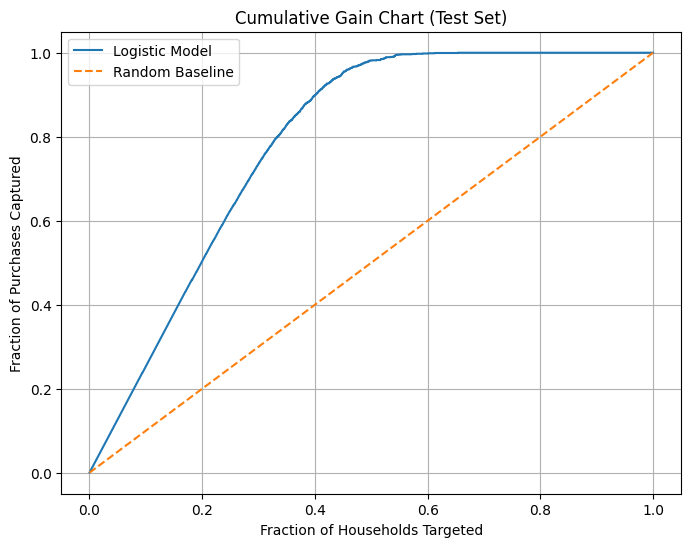

If the firm targets the top 20% of households by predicted probability,
it captures approximately 50.41% of all purchases.


In [14]:
# 1. Get predicted probabilities on test set
p_test = pipe_logit.predict_proba(X_test)[:, 1]

# 2. Create dataframe for sorting
gain_df = (
    pd.DataFrame({
        "y_true": y_test.values,
        "p_hat": p_test
    })
    .sort_values("p_hat", ascending=False)
    .reset_index(drop=True)
)

# 3. Compute cumulative metrics
gain_df["cum_samples"] = np.arange(1, len(gain_df) + 1) / len(gain_df)
gain_df["cum_positives"] = gain_df["y_true"].cumsum()
total_positives = gain_df["y_true"].sum()
gain_df["cum_gain"] = gain_df["cum_positives"] / total_positives

# 4. Plot cumulative gain curve
plt.figure(figsize=(8,6))
plt.plot(gain_df["cum_samples"], gain_df["cum_gain"], label="Logistic Model")
plt.plot([0,1], [0,1], linestyle="--", label="Random Baseline")

plt.xlabel("Fraction of Households Targeted")
plt.ylabel("Fraction of Purchases Captured")
plt.title("Cumulative Gain Chart (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

# 5. Managerial summary example: Top 20%
top_20_index = int(0.20 * len(gain_df))
top_20_capture = gain_df.loc[top_20_index, "cum_gain"]

print(f"If the firm targets the top 20% of households by predicted probability,")
print(f"it captures approximately {top_20_capture:.2%} of all purchases.")

In [15]:
# --- Simple interpretation: largest logistic regression coefficients ---

# Extract feature names after preprocessing
feat_names = pipe_logit.named_steps["prep"].get_feature_names_out()
coefs = pipe_logit.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df = coef_df.sort_values("coef")

print("Most negative coefficients (lower purchase propensity):")
display(coef_df.head(10))

print("\nMost positive coefficients (higher purchase propensity):")
display(coef_df.tail(10))


Most negative coefficients (lower purchase propensity):


,feature,coef
4,num__family_size,-6.164771
3,num__age,-2.149192
20,cat__state_IN,-0.605633
30,cat__state_MS,-0.577243
43,cat__state_PA,-0.575347
25,cat__state_MD,-0.563602
41,cat__state_OK,-0.531423
57,cat__sex_M,-0.489503
56,cat__sex_F,-0.461182
10,cat__state_CA,-0.459097



Most positive coefficients (higher purchase propensity):


,feature,coef
13,cat__state_DE,0.222351
35,cat__state_NH,0.251005
11,cat__state_CO,0.314905
22,cat__state_KY,0.327989
37,cat__state_NM,0.420357
47,cat__state_TN,0.425439
44,cat__state_RI,0.484321
16,cat__state_HI,0.772536
46,cat__state_SD,0.816452
21,cat__state_KS,0.877617


---

**Question 6.** Use the logistic regression baseline and the associated gain chart.

- How would you use the gain chart to explain (in plain language) whether the model adds value over random targeting?
- What is one reason a model with a better ROC AUC might still be *worse* for the firm's operational objective?
- Which variables appear most influential in predicting purchase? Do they make sense? Explain.

---

**Answer**

1. How does the gain chart show whether the model adds value?
The gain chart compares the model’s targeting performance against a random baseline.
- The dashed line represents random targeting: If we target 20% of households, we capture ~20% of purchases.
- The model curve shows what happens when we target households ranked by predicted purchase probability.

From the chart, the model curve lies well above the random line, especially in the early portion. For example, targeting the top 20% of households captures substantially more than 20% of purchases. 

2. Why might a model with better ROC AUC still be worse operationally?
ROC AUC measures overall ranking quality across all thresholds, but firms often care about specific operational decisions, such as targeting the top 10–20% of customers. A model could have a higher ROC AUC but:
- Perform worse in the upper tail
- Misrank the very best customers, even if it ranks the rest well





## Main Question Prompt

Your goal is to build the most effective prediction rule for `purchase` that you can.

There is no single correct answer. A strong solution will articulate a clear business objective, choose evaluation metrics aligned with that objective, compare multiple models and tuning choices, and communicate the result clearly to a manager.

---

**Question 7.** Expand away from the logistic regression baseline. Build and compare at least **two** additional prediction rules (e.g., regularized logistic regression, decision trees, random forests, gradient boosting, kNN, or another method). Be explicit about preprocessing choices, hyperparameter tuning (validation set or cross-validation), and why the model you select is the best fit for your objective.

---

**Question 8.** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation suitable for a **10-minute** presentation to a pricing/marketing manager who cares about business outcomes, is wary of opaque black-box solutions, and wants to understand risks and trade-offs.

Your deck should include
1. The business objective and how the model would be used operationally.
2. How you evaluated performance (in business terms).
3. Key results (illustrating how the model supports your objective).
4. What seems to drive predictions (interpretability at the right level).
5. Discussion of risks and caveats.


### Potential answer

So far, we have used logistic regression as a baseline model. That is a useful starting point because it is simple, interpretable, and often performs reasonably well. But in practice, firms usually compare several prediction rules before deciding which one to use.

In this section, we will build and compare multiple models for predicting purchase. We will:

- keep the same train / validation / test structure,
- choose preprocessing that matches each model,
- tune key hyperparameters using the validation set,
- compare models using metrics that matter for business decisions.

Our goal is not just to maximize a statistical score mechanically. Instead, we want to find the model that is most useful for the firm’s pricing and targeting objective.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid

In [17]:
# Preprocessing for models that benefit from scaling (such as logistic regression)
preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# Preprocessing for tree-based models
# Trees do not require scaling, but we still encode categorical variables.
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

In [18]:
def eval_classifier(pipe, X, y, name="set"):
    """
    Evaluate a fitted classification pipeline on a given dataset.
    """
    p = pipe.predict_proba(X)[:, 1]
    yhat = (p >= 0.5).astype(int)

    out = {
        "set": name,
        "accuracy": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "f1": f1_score(y, yhat, zero_division=0),
        "roc_auc": roc_auc_score(y, p),
        "log_loss": log_loss(y, p),
    }
    return out

Tune regularized logistic regression

In [19]:
# We will tune the regularization strength C.
# Smaller C = more regularization, larger C = less regularization.

logit_results = []

for C in [0.01, 0.1, 1, 10]:
    pipe = Pipeline([
        ("prep", preprocess_linear),
        ("model", LogisticRegression(max_iter=3000, C=C))
    ])
    
    pipe.fit(X_train, y_train)
    
    val_metrics = eval_classifier(pipe, X_val, y_val, name="val")
    val_metrics["model"] = "logistic_regression"
    val_metrics["hyperparameters"] = f"C={C}"
    
    logit_results.append(val_metrics)

logit_results_df = pd.DataFrame(logit_results).sort_values(
    ["roc_auc", "log_loss"], ascending=[False, True]
)

logit_results_df

,set,accuracy,precision,recall,f1,roc_auc,log_loss,model,hyperparameters
0,val,0.907122,0.890878,0.870833,0.880742,0.972732,0.244450,logistic_regression,C=0.01
1,val,0.907778,0.889077,0.875000,0.881982,0.972600,0.208147,logistic_regression,C=0.1
2,val,0.906794,0.886172,0.875833,0.880972,0.972264,0.207966,logistic_regression,C=1
3,val,0.907450,0.887015,0.876667,0.881811,0.972067,0.209070,logistic_regression,C=10


Tune decision tree

In [20]:
tree_results = []

tree_grid = {
    "max_depth": [3, 5, 8, 12],
    "min_samples_leaf": [10, 25, 50]
}

for params in ParameterGrid(tree_grid):
    pipe = Pipeline([
        ("prep", preprocess_tree),
        ("model", DecisionTreeClassifier(
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42
        ))
    ])
    
    pipe.fit(X_train, y_train)
    
    val_metrics = eval_classifier(pipe, X_val, y_val, name="val")
    val_metrics["model"] = "decision_tree"
    val_metrics["hyperparameters"] = str(params)
    
    tree_results.append(val_metrics)

tree_results_df = pd.DataFrame(tree_results).sort_values(
    ["roc_auc", "log_loss"], ascending=[False, True]
)

tree_results_df.head(10)

,set,accuracy,precision,recall,f1,roc_auc,log_loss,model,hyperparameters
4,val,0.896948,0.913246,0.815833,0.861796,0.969005,0.229451,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 25}"
5,val,0.896291,0.913858,0.813333,0.860670,0.968884,0.229892,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 50}"
3,val,0.895635,0.909851,0.815833,0.860281,0.968371,0.230806,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 10}"
8,val,0.903512,0.898768,0.850833,0.874144,0.968268,0.246252,decision_tree,"{'max_depth': 8, 'min_samples_leaf': 50}"
11,val,0.903512,0.898768,0.850833,0.874144,0.967428,0.287053,decision_tree,"{'max_depth': 12, 'min_samples_leaf': 50}"
7,val,0.900558,0.871582,0.876667,0.874117,0.963194,0.373421,decision_tree,"{'max_depth': 8, 'min_samples_leaf': 25}"
6,val,0.896291,0.874576,0.860000,0.867227,0.960291,0.454902,decision_tree,"{'max_depth': 8, 'min_samples_leaf': 10}"
10,val,0.901543,0.876884,0.872500,0.874687,0.959741,0.554805,decision_tree,"{'max_depth': 12, 'min_samples_leaf': 25}"
0,val,0.903183,0.850503,0.915000,0.881574,0.955149,0.245422,decision_tree,"{'max_depth': 3, 'min_samples_leaf': 10}"
1,val,0.903183,0.850503,0.915000,0.881574,0.955149,0.245422,decision_tree,"{'max_depth': 3, 'min_samples_leaf': 25}"


Tune random forest

In [21]:
rf_results = []

rf_grid = {
    "n_estimators": [100, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [5, 20]
}

for params in ParameterGrid(rf_grid):
    pipe = Pipeline([
        ("prep", preprocess_tree),
        ("model", RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    pipe.fit(X_train, y_train)
    
    val_metrics = eval_classifier(pipe, X_val, y_val, name="val")
    val_metrics["model"] = "random_forest"
    val_metrics["hyperparameters"] = str(params)
    
    rf_results.append(val_metrics)

rf_results_df = pd.DataFrame(rf_results).sort_values(
    ["roc_auc", "log_loss"], ascending=[False, True]
)

rf_results_df.head(10)

,set,accuracy,precision,recall,f1,roc_auc,log_loss,model,hyperparameters
8,val,0.903183,0.895197,0.854167,0.874200,0.965603,0.269101,random_forest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_..."
9,val,0.904496,0.896251,0.856667,0.876012,0.965355,0.271195,random_forest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_..."
4,val,0.888087,0.892955,0.813333,0.851287,0.963386,0.329429,random_forest,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es..."
5,val,0.885789,0.890110,0.810000,0.848168,0.962465,0.333886,random_forest,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es..."
10,val,0.888087,0.892955,0.813333,0.851287,0.961691,0.317623,random_forest,"{'max_depth': None, 'min_samples_leaf': 20, 'n..."
11,val,0.883492,0.886551,0.807500,0.845181,0.961100,0.317770,random_forest,"{'max_depth': None, 'min_samples_leaf': 20, 'n..."
6,val,0.884477,0.894786,0.800833,0.845207,0.960157,0.356306,random_forest,"{'max_depth': 10, 'min_samples_leaf': 20, 'n_e..."
7,val,0.884148,0.888176,0.807500,0.845919,0.959650,0.350848,random_forest,"{'max_depth': 10, 'min_samples_leaf': 20, 'n_e..."
3,val,0.884148,0.887466,0.808333,0.846053,0.955494,0.445024,random_forest,"{'max_depth': 5, 'min_samples_leaf': 20, 'n_es..."
2,val,0.882507,0.895677,0.794167,0.841873,0.954917,0.450634,random_forest,"{'max_depth': 5, 'min_samples_leaf': 20, 'n_es..."


Combine validation results and compare best versions

In [22]:
all_val_results = pd.concat(
    [logit_results_df, tree_results_df, rf_results_df],
    axis=0
).reset_index(drop=True)

all_val_results.sort_values(["roc_auc", "log_loss"], ascending=[False, True]).head(15)

,set,accuracy,precision,recall,f1,roc_auc,log_loss,model,hyperparameters
0,val,0.907122,0.890878,0.870833,0.880742,0.972732,0.244450,logistic_regression,C=0.01
1,val,0.907778,0.889077,0.875000,0.881982,0.972600,0.208147,logistic_regression,C=0.1
2,val,0.906794,0.886172,0.875833,0.880972,0.972264,0.207966,logistic_regression,C=1
3,val,0.907450,0.887015,0.876667,0.881811,0.972067,0.209070,logistic_regression,C=10
4,val,0.896948,0.913246,0.815833,0.861796,0.969005,0.229451,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 25}"
5,val,0.896291,0.913858,0.813333,0.860670,0.968884,0.229892,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 50}"
6,val,0.895635,0.909851,0.815833,0.860281,0.968371,0.230806,decision_tree,"{'max_depth': 5, 'min_samples_leaf': 10}"
7,val,0.903512,0.898768,0.850833,0.874144,0.968268,0.246252,decision_tree,"{'max_depth': 8, 'min_samples_leaf': 50}"
8,val,0.903512,0.898768,0.850833,0.874144,0.967428,0.287053,decision_tree,"{'max_depth': 12, 'min_samples_leaf': 50}"
16,val,0.903183,0.895197,0.854167,0.874200,0.965603,0.269101,random_forest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_..."


Refit the best version of each model and compare on validation set

In [23]:
# Best logistic regression
best_logit_row = logit_results_df.iloc[0]
best_logit_C = float(best_logit_row["hyperparameters"].split("=")[1])

best_logit = Pipeline([
    ("prep", preprocess_linear),
    ("model", LogisticRegression(max_iter=3000, C=best_logit_C))
])

best_logit.fit(X_train, y_train)

# Best decision tree
best_tree_row = tree_results_df.iloc[0]
best_tree_params = eval(best_tree_row["hyperparameters"])

best_tree = Pipeline([
    ("prep", preprocess_tree),
    ("model", DecisionTreeClassifier(
        max_depth=best_tree_params["max_depth"],
        min_samples_leaf=best_tree_params["min_samples_leaf"],
        random_state=42
    ))
])

best_tree.fit(X_train, y_train)

# Best random forest
best_rf_row = rf_results_df.iloc[0]
best_rf_params = eval(best_rf_row["hyperparameters"])

best_rf = Pipeline([
    ("prep", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=best_rf_params["n_estimators"],
        max_depth=best_rf_params["max_depth"],
        min_samples_leaf=best_rf_params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    ))
])

best_rf.fit(X_train, y_train)

comparison_val = pd.DataFrame([
    {**eval_classifier(best_logit, X_val, y_val, "val"), "model": "best_logit"},
    {**eval_classifier(best_tree, X_val, y_val, "val"), "model": "best_tree"},
    {**eval_classifier(best_rf, X_val, y_val, "val"), "model": "best_random_forest"},
])

comparison_val[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "log_loss"]].sort_values(
    ["roc_auc", "log_loss"], ascending=[False, True]
)

,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,best_logit,0.907122,0.890878,0.870833,0.880742,0.972732,0.244450
1,best_tree,0.896948,0.913246,0.815833,0.861796,0.969005,0.229451
2,best_random_forest,0.903183,0.895197,0.854167,0.874200,0.965603,0.269101


Choose a final model and evaluate on the test set

In [ ]:
final_model = best_logit
final_model_name = "Logistic"

# Refit on train + validation combined before final test evaluation
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

final_model.fit(X_train_final, y_train_final)

final_test_results = pd.DataFrame([
    {**eval_classifier(final_model, X_test, y_test, "test"), "model": final_model_name}
])

final_test_results

,set,accuracy,precision,recall,f1,roc_auc,log_loss,model
0,test,0.914103,0.901797,0.877577,0.889522,0.977862,0.220925,Logistic


Short summary table of all final candidate models on test set

In [27]:
# Refit each best model on train + validation
best_logit.fit(X_train_final, y_train_final)
best_tree.fit(X_train_final, y_train_final)
best_rf.fit(X_train_final, y_train_final)

final_comparison_test = pd.DataFrame([
    {**eval_classifier(best_logit, X_test, y_test, "test"), "model": "Best Logistic Regression"},
    {**eval_classifier(best_tree, X_test, y_test, "test"), "model": "Best Decision Tree"},
    {**eval_classifier(best_rf, X_test, y_test, "test"), "model": "Best Random Forest"},
])

final_comparison_test[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "log_loss"]].sort_values(
    ["roc_auc", "log_loss"], ascending=[False, True]
)

,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,Best Logistic Regression,0.914103,0.901797,0.877577,0.889522,0.977862,0.220925
1,Best Decision Tree,0.911149,0.868609,0.912555,0.890040,0.974383,0.220087
2,Best Random Forest,0.912380,0.898783,0.876327,0.887413,0.973024,0.249762


### Talking points for Question 8

Question 8 asks for a short presentation to a pricing / marketing manager. Rather than producing slides, the following bullet points summarize what that presentation could cover. 

**1. Business objective and how the model would be used operationally.**

- The prediction target is `purchase` — did this household buy at the offered price in this period? 
- Possible operational uses:
    - **Targeting**: rank households by predicted purchase probability and concentrate promotional spend (coupons, personalized offers) on the top of the list — just like "who do we call?" in the bank telemarketing setting.
    - **Pricing support**: for a given household, use the model to compare predicted purchase probability at alternative candidate prices, then combine with margin to rank prices by expected contribution.
Other objectives would work.

**2. How we evaluated performance (in business terms).**

- Accuracy on its own is misleading because purchases are rare
    - **Confusion matrix + precision, recall, specificity, F1** at the operating threshold — so the manager can see what kinds of errors the model is making.
    - **ROC AUC** for overall ranking quality.
    - **Log loss** for probability calibration — this is what feeds any expected-profit or expected-contribution calculation.
    - **Cumulative gain chart and lift** — the manager-friendly picture: if we contact the top X% of households ranked by predicted probability, what fraction of purchasers do we reach vs. random contact?


**3. Key results.**

- Four model families were compared on the validation set: the logistic-regression baseline, a regularized logistic regression (tuned over `C`), a decision tree (tuned on depth and min-leaf), and a random forest (tuned on trees, depth, and min-leaf). The best version of each was refit on train + validation and scored on the held-out test set.
- The recommended final model is the regularized logistic regression: it is competitive with the tree-based models on ROC AUC and log loss, and it is much easier to explain and to audit — a meaningful advantage given the manager's stated skepticism of black-box models. 
- The gain chart shows the model's value concretely: targeting the top decile of predicted buyers captures materially more than 10% of realized purchases, which is exactly the regime a marketing campaign operates in.
- 
**4. What drives predictions (interpretability at the right level).**

- Because the chosen model is logistic regression, we can read drivers directly off the standardized coefficients:
    - **Price** is the dominant driver — higher price lowers predicted purchase probability, as expected.
    - **Prior brand interactions** are the strongest non-price signal — repeat engagers convert more, which supports loyalty-style retention tactics.
    - **Household demographics** (income, family size, age) contribute intuitive but secondary effects.
- For a manager presentation I would supplement the coefficients with the class interpretation tools, computed on the chosen model (or on the random-forest challenger):
    - **Drop-column and permutation importance** to rank features by their contribution to out-of-sample performance. These are the same tools we used on the bank random forest.
    - **Partial dependence plots** for the most interesting features — especially `price` — to show the manager *how* predicted purchase probability moves as the feature changes, holding everything else fixed. This is the most persuasive black-box interpretation device for a non-technical audience.


**5. Risks and caveats.**

- **Random (not time-based) split.** Fine if the data-generating process is roughly stable, but if the firm changes pricing policy, runs a promo, or macro conditions move, a forward-looking time-based split is more honest. The Case 1 return-forecasting problem made this point directly.
- **Correlational, not causal.** "Higher price → lower predicted probability" in the model is *associational*. Acting on it as a pricing lever requires either an A/B test / price experiment or an explicit causal identification argument. This is the "correlation does not imply causation" point from class, and it matters more here than in the bank example because the firm is considering *setting* price.
- **Fairness.** The model uses race, sex, and state as predictors. Before any live use, a fairness review is essential; some features may need to be dropped for legal or ethical reasons even if they improve predictive accuracy.
- **Monitoring plan.** Re-score monthly. Track ROC AUC, log loss, and calibration (predicted vs. actual purchase rate by probability decile) over time. Retrain when calibration drifts or when the gain chart in the top decile deteriorates.
